In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
!ls "/content/drive/MyDrive/Colab Notebooks"

 Brain_Tumor		     DailyChallengeW2D3.ipynb  'Flower Classification.zip'
 Brain.zip		     DailyChallengeW2D5.ipynb   Foodie_Analysis.pptx
 Cats_Dogs		     Exercise1+2+3w2d3.ipynb    Foodie_Analysis_Presentation.pptx
 challenge1.ipynb	     Exercise1.ipynb	        HackathonD5W3.ipynb
 challenge2.ipynb	    'Exercise 2.ipynb'	        metadata.csv
 challengepage1w2d3.ipynb    Exercise3.ipynb	        MiniProjectW2.ipynb
 challengepage2w2d3.ipynb    Exercise4+5.ipynb	        MiniProjectW3.ipynb
 ClassChallenge1D2W4.ipynb   Exercise4w2d3.ipynb        MiniProjetD5W4.ipynb
 ClassChallenge3D2W4.ipynb   Exercises1+2+3D2W2.ipynb   NOTES_D1W3.ipynb
 DailyChallengeD1W3.ipynb    Exercises4D2W2.ipynb       NOTES-D2W3.ipynb
 DailyChallengeD1W4.ipynb    Exercises5D2W2.ipynb       NOTES-D3W3.ipynb
 DailyChallengeD2W3.ipynb    Exercises6D2W2.ipynb       NOTES_plots_day4.ipynb
 DailyChallengeD2W4.ipynb    ExercisesD1W3.ipynb        test.ipynb
 DailyChallengeD3W3.ipynb    ExercisesD1W4.ipynb        TrainingD

In [40]:
import os

# Define the correct path to your dataset inside Google Drive
base_dir = "/content/drive/MyDrive/Colab Notebooks/Cats_Dogs"

# Define paths for training and testing
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Verify if paths exist
print("Train directory exists:", os.path.exists(train_dir))
print("Test directory exists:", os.path.exists(test_dir))

Train directory exists: True
Test directory exists: True


In [41]:
# Create a training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize images
    rotation_range=40,  # Rotate images up to 40 degrees
    width_shift_range=0.2,  # Randomly shift width
    height_shift_range=0.2,  # Randomly shift height
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Zoom in/out
    horizontal_flip=True,  # Flip images horizontally
    validation_split=0.2  # Split 20% for validation
)

# Load training images (80% of train/)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # Resize images to 150x150 pixels
    batch_size=32,
    class_mode="binary",
    subset="training"
)

# Load validation images (20% of train/)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 202 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
# 2. Build the Model
# Creating the CNN model:

# Create a CNN with 3 convolutional layers.
# Use ReLU activation for feature extraction.
# Use MaxPooling to reduce complexity.
# Add Dropout (0.5) to prevent overfitting.
# Use Sigmoid activation in the output layer (since it's binary classification).

In [42]:
# Importing Keras and Build the Model

from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    # First Convolutional Layer
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2,2),

    # Second Convolutional Layer
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Third Convolutional Layer
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Flatten the feature maps to a fully connected layer
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    layers.Dense(1, activation="sigmoid")  # Output layer (Binary classification)
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Summary of the model
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

3. Train the Model
after building the CNN model, we train it.

- Train the model on augmented training data.
- Use validation data to monitor performance.
- Train for 15 epochs with a batch size of 32.

In [43]:
# To train the Model

history = model.fit(
    train_generator,  # Training data
    epochs=15,  # Number of epochs
    validation_data=validation_generator  # Validation data
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 58s 8s/step - accuracy: 0.5131 - loss: 0.7880 - val_accuracy: 0.4400 - val_loss: 0.7090
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5156 - loss: 0.6990 - val_accuracy: 0.4200 - val_loss: 0.6954
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5294 - loss: 0.6816 - val_accuracy: 0.5800 - val_loss: 0.6873
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6760 - loss: 0.6709 - val_accuracy: 0.5800 - val_loss: 0.6847
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5573 - loss: 0.6784 - val_accuracy: 0.5800 - val_loss: 0.6850
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6637 - loss: 0.6374 - val_accuracy: 0.5200 - val_loss: 0.7085
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6760 - loss: 0.6281 - val_accuracy: 0.5200 - val_loss: 0.6994
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6858 - loss: 0.6316 - val_accuracy: 0.5000 - val_loss: 0.7165
Epoch 9/

4. Evaluate the Model
-Now that we have trained the model, we need to analyze its performance to detect overfitting.

-in this step we should:

- Plot training vs. validation accuracy to check learning progress.
- Plot training vs. validation loss to detect overfitting.

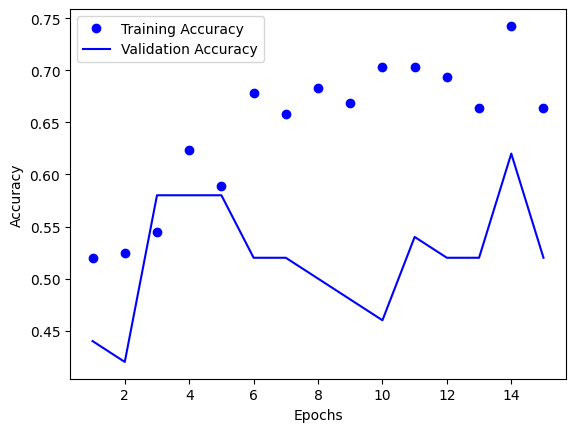

In [45]:
# Plotting training and validation accuracy

import matplotlib.pyplot as plt

# Extract accuracy and validation accuracy
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.plot(epochs, acc, "bo", label="Training Accuracy")
plt.plot(epochs, val_acc, "b", label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Accuracy Plot:

- Training accuracy is improving.
- Validation accuracy is fluctuating (unstable learning).

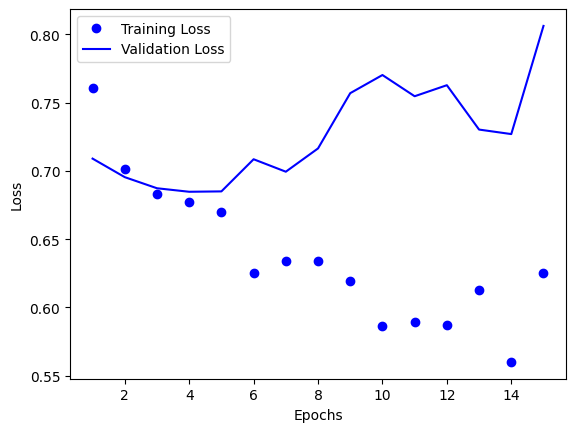

In [46]:
# Plotting Training and Validation Loss

# Extract loss and validation loss
loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Plot loss
plt.plot(epochs, loss, "bo", label="Training Loss")
plt.plot(epochs, val_loss, "b", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Loss Plot:

- Training loss is decreasing (good).
- Validation loss increases after a few epochs (bad) → Overfitting detected.

5. Bonus: Retry Training After Data Augmentation
Since we detected overfitting, we will now enhance data augmentation to improve model generalization:


- Applying horizontal flip, rotation, and zoom augmentation.
- Ensuring the model never sees the same image twice during training.
- Retraining the model using this improved augmented dataset.

In [47]:
# Applying Advanced Data Augmentation
# we update the training data generator to use stronger augmentation.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Improved Data Augmentation for Training
image_gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,  # Rotate up to 45 degrees
    width_shift_range=0.15,  # Shift width
    height_shift_range=0.15,  # Shift height
    horizontal_flip=True,  # Flip images
    zoom_range=0.5  # Zoom in/out
)


In [48]:
# Loading training images with new augmentation
train_data_gen = image_gen_train.flow_from_directory(
    train_dir,
    batch_size=32,
    shuffle=True,
    target_size=(150, 150),
    class_mode="binary"
)

Found 252 images belonging to 2 classes.


In [49]:
# Creating a Validation Data Generator (No Augmentation)
# we keep the data simple since validation data should not be altered,

image_gen_val = ImageDataGenerator(rescale=1./255)

val_data_gen = image_gen_val.flow_from_directory(
    train_dir,  # Still using 'train' for validation (20% split)
    batch_size=32,
    target_size=(150, 150),
    class_mode="binary",
    subset="validation"
)

Found 0 images belonging to 2 classes.


In [52]:
image_gen_val = ImageDataGenerator(rescale=1./255, validation_split=0.2)  # 20% for validation

val_data_gen = image_gen_val.flow_from_directory(
    train_dir,  # Still using 'train' for validation (split 20%)
    batch_size=32,
    target_size=(150, 150),
    class_mode="binary",
    subset="validation"  # <== Important: This tells it to use validation split
)

Found 50 images belonging to 2 classes.


In [53]:
print("Number of training images:", train_data_gen.samples)
print("Number of validation images:", val_data_gen.samples)

Number of training images: 252
Number of validation images: 50


In [54]:
# Retraining the Model with Augmented Data
# Now we train the model again using the new augmented dataset.

history_augmented = model.fit(
    train_data_gen,  # Augmented training data
    epochs=10,  # Train for 10 epochs
    validation_data=val_data_gen  # Standard validation data
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6657 - loss: 0.6005 - val_accuracy: 0.5400 - val_loss: 0.6991
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7131 - loss: 0.5850 - val_accuracy: 0.5400 - val_loss: 0.6988
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7409 - loss: 0.5390 - val_accuracy: 0.5800 - val_loss: 0.6725
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7029 - loss: 0.5796 - val_accuracy: 0.6200 - val_loss: 0.6784
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6626 - loss: 0.6229 - val_accuracy: 0.6400 - val_loss: 0.6258
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6720 - loss: 0.5871 - val_accuracy: 0.6600 - val_loss: 0.5984
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7032 - loss: 0.5949 - val_accuracy: 0.5000 - val_loss: 0.6976
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6999 - loss: 0.5463 - val_accuracy: 0.5200 - val_loss: 0.6799
Epoch 9/

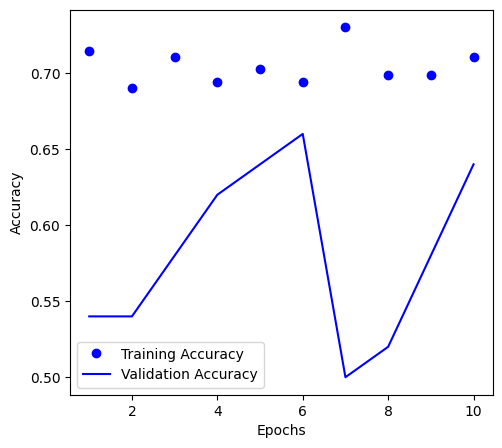

In [55]:
#  Comparing Performance Before & After Augmentation

import matplotlib.pyplot as plt

# Extract metrics
acc = history_augmented.history["accuracy"]
val_acc = history_augmented.history["val_accuracy"]
loss = history_augmented.history["loss"]
val_loss = history_augmented.history["val_loss"]
epochs = range(1, len(acc) + 1)

# Plottingg accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "bo", label="Training Accuracy")
plt.plot(epochs, val_acc, "b", label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

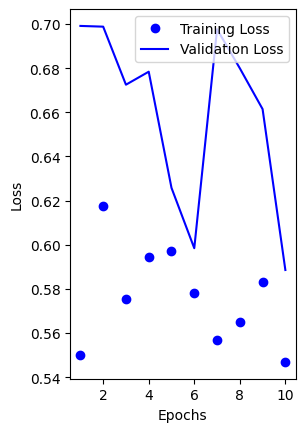

In [56]:
# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "bo", label="Training Loss")
plt.plot(epochs, val_loss, "b", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [57]:
# To Load and Predict on Test Images

import numpy as np
from tensorflow.keras.preprocessing import image
import os

# List all test images
test_images = os.listdir(test_dir)  # Get filenames

for img_name in test_images:
    img_path = os.path.join(test_dir, img_name)  # Full path to image

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(150, 150))  # Resize
    img_array = image.img_to_array(img)  # Convert to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize

    # Make a prediction
    prediction = model.predict(img_array)

    # Interpret the result
    label = "Dog" if prediction[0][0] > 0.5 else "Cat"
    print(f"Image: {img_name} → Predicted as: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Image: 12351.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Image: 12363.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image: 12361.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Image: 12362.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Image: 12360.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image: 12500.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image: 12493.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image: 12354.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Image: 12364.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Image: 12499.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Image: 12498.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image: 12350.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image: 12359.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━

*****RESULTS ARE NOT ALWAYS ACCURATE (IT'S SOMETOMES MISTAKING DOGS FOR CATS)*****

In [58]:
# 1. Reduce Overfitting by Increasing Dropout
# current model might memorize training data too much.
# We should try increasing dropout in the dense layer to reduce overfitting.

# Modifying the model:

from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    # First Convolutional Layer
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2,2),

    # Second Convolutional Layer
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Third Convolutional Layer
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Flatten the feature maps to a fully connected layer
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.6),  # Increase dropout from 0.5 to 0.6
    layers.Dense(1, activation="sigmoid")  # Output layer (Binary classification)
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
# Improve Data Augmentation (Reduce Distortion)
#  previous data augmentation might be too aggressive, causing the model to struggle.

# Modifying augmentation:
image_gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,  # Reduce rotation (was 45)
    width_shift_range=0.1,  # Reduce shifting (was 0.15)
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2  # Reduce zoom (was 0.5)
)

train_data_gen = image_gen_train.flow_from_directory(
    train_dir,
    batch_size=32,
    shuffle=True,
    target_size=(150, 150),
    class_mode="binary"
)


Found 252 images belonging to 2 classes.


In [60]:
# training the model
history = model.fit(
    train_data_gen,
    epochs=20,  # Increased from 10 to 15
    validation_data=val_data_gen
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4935 - loss: 1.6300 - val_accuracy: 0.5600 - val_loss: 0.6915
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5581 - loss: 0.6998 - val_accuracy: 0.5600 - val_loss: 0.6883
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5992 - loss: 0.6829 - val_accuracy: 0.5600 - val_loss: 0.6886
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.3932 - loss: 0.7016 - val_accuracy: 0.5400 - val_loss: 0.6925
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5727 - loss: 0.6855 - val_accuracy: 0.5600 - val_loss: 0.6838
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6097 - loss: 0.6777 - val_accuracy: 0.4600 - val_loss: 0.7231
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4900 - loss: 0.6896 - val_accuracy: 0.5400 - val_loss: 0.6813
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6263 - loss: 0.6662 - val_accuracy: 0.5000 - val_loss: 0.7104
Epoch 9/

In [61]:
# Re-Testing on Unlabeled Images
# Once we retrained the model, we re-run the test script:

import numpy as np
from tensorflow.keras.preprocessing import image
import os

# List all test images
test_images = os.listdir(test_dir)

for img_name in test_images:
    img_path = os.path.join(test_dir, img_name)

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Make a prediction
    prediction = model.predict(img_array)

    # Interpret the result
    label = "Dog" if prediction[0][0] > 0.5 else "Cat"
    print(f"Image: {img_name} → Predicted as: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Image: 12351.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Image: 12363.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Image: 12361.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image: 12362.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image: 12360.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Image: 12500.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image: 12493.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image: 12354.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Image: 12364.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Image: 12499.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image: 12498.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Image: 12350.jpg → Predicted as: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Image: 12359.jpg → Predicted as: Cat
1/1 ━━━━━━━━━━━━━━━━━━━